### **Mapping Mangrove Distribution Based on AMMI  (Suyarso & Avianto, 2022)**
Using **Geemap** (Wu, 2020) and **Cartoee** (Markert, 2019) Layout

---

 **Overview**
This analysis demonstrates the application of the **Automatic Mangrove Map and Index (AMMI)** algorithm using Python-based geospatial tools to monitor mangrove ecosystems.

---

**Tools and Libraries**
- **ee (Earth Engine API)**  
  The core interface used to access Google Earth Engine’s cloud-based geospatial datasets and high-performance computing power.

- **geemap & geemap.cartoee**  
  Used to visualize GEE layers. `cartoee` specifically allows the creation of publication-quality static maps by integrating Earth Engine data with the `matplotlib` plotting environment.

- **matplotlib & cartopy**  
  `matplotlib` handles the overall figure layout, while `cartopy` provides tools for map projections, coordinate reference systems (CRS), and gridline generation.

---

 AMMI Index (Automatic Mangrove Map and Index)

The **Automatic Mangrove Map and Index (AMMI)** is a specialized vegetation index designed to:
- Identify mangrove extents automatically  
- Estimate canopy density  

Unlike general vegetation indices, AMMI is optimized to distinguish mangroves from other coastal features.

### **Developed By**
Suyarso and P. Avianto (2022)  
Research Center for Oceanography, National Research and Innovation Agency (BRIN, formerly LIPI), Indonesia.


---

**Algorithm and Thresholding**

The AMMI formula is derived from reflectance values ($\rho$) of:
- NIR (Near Infrared)  
- SWIR1 (Shortwave Infrared 1)  
- Red band  

 **1. Land Delineation**
$$
\frac{\rho_{NIR} - \rho_{Red}}{\rho_{Red} + \rho_{SWIR1}}
$$

This component strengthens terrestrial signals while suppressing water and marine features.

---

 **2. Mangrove classification**
$$
\frac{\rho_{NIR} - \rho_{SWIR1}}{\rho_{SWIR1} - 0.65 \times \rho_{Red}}
$$

This part is calibrated to capture mangrove extent and canopy density.

---

 **3. Complete AMMI Formula**
$$
AMMI =
\frac{\rho_{NIR} - \rho_{Red}}{\rho_{Red} + \rho_{SWIR1}}
\times
\frac{\rho_{NIR} - \rho_{SWIR1}}{\rho_{SWIR1} - 0.65 \times \rho_{Red}}
$$

---

**Classification Thresholds**

- **Mangrove Binary Map**  
  $$ AMMI > 6 $$  
  → Classified as mangrove  

- **Mangrove Density Index**  
  $$ AMMI > 5 $$  
  → Used to visualize canopy density variation  

---

 Prepared By
**Defani Arman Alfitriansyah**  
Faculty of Forestry, Universitas Kuningan  

---



**Install Library**

In [ ]:
#!pip install ee
#!pip install geemap
#!pip install cartopy

**Code**

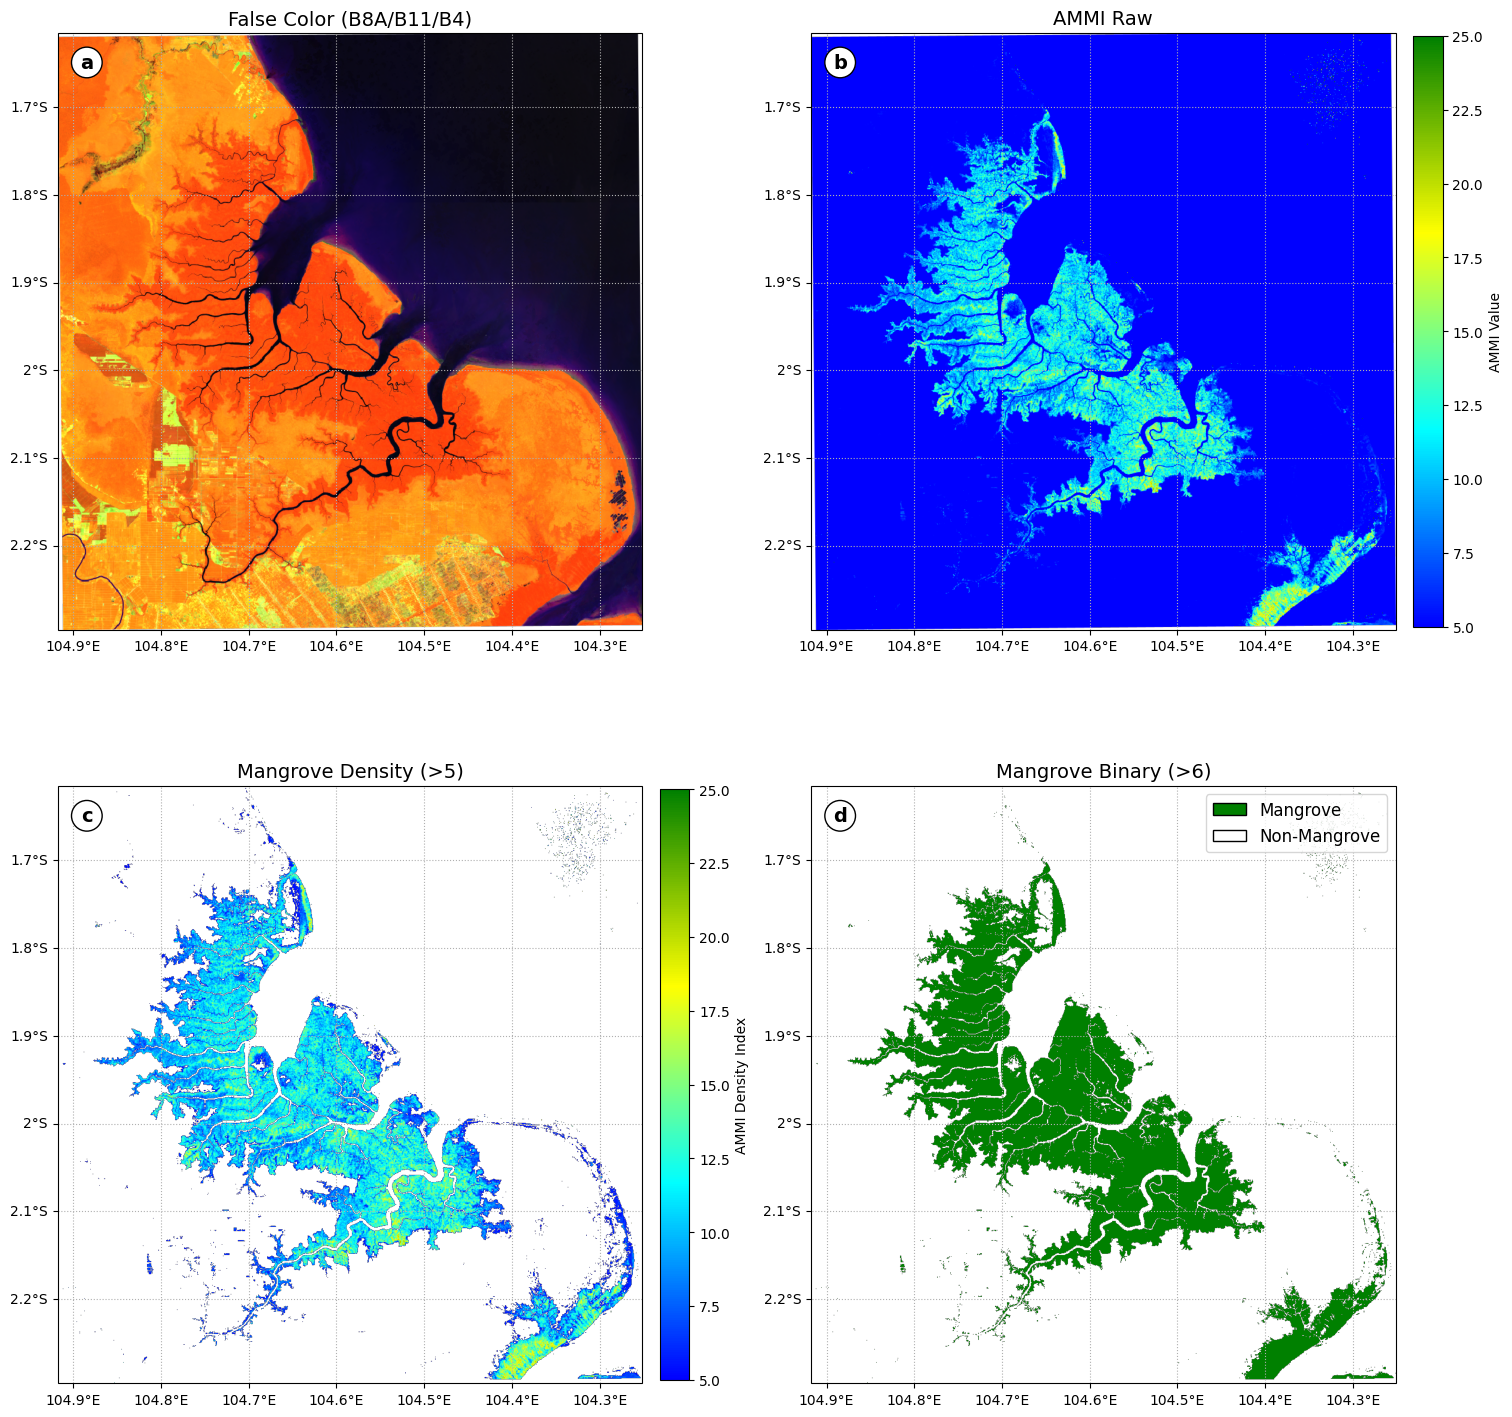

In [14]:
import ee
import geemap.cartoee as cartoee
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch

#GEOAXES PREPARATION IN CARTOEE
from cartopy.mpl.geoaxes import GeoAxes
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

cartoee.GeoAxes = cartoee.GeoAxesSubplot = GeoAxes
cartoee.ccrs = ccrs
cartoee.LONGITUDE_FORMATTER = LONGITUDE_FORMATTER
cartoee.LATITUDE_FORMATTER = LATITUDE_FORMATTER

# INITIALIZE EARTH ENGINE
ee.Authenticate()
ee.Initialize(project='ee-defaniarman')

# DEFINE REGION OF INTEREST FROM ASSET
batas_wilayah = ee.FeatureCollection(
    "projects/ee-defaniarman/assets/areakajian"
)

# LOAD CLOUD SCORE PLUS COLLECTION
csPlus = ee.ImageCollection(
    'GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED'
)

# FUNCTION TO APPLY CLOUD SCORE PLUS MASK
def maskS2CSPlus(image):
    qa = image.select('cs_cdf')
    return image.updateMask(qa.gte(0.60))

# BASE SENTINEL-2 COLLECTION
s2_base = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(batas_wilayah)
    .filterDate('2024-01-01', '2025-12-01')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
)

# FUNCTION TO SCALE REFLECTANCE
def scale_image(img):
    return img.multiply(0.0001).copyProperties(
        img, ['system:time_start']
    )

# APPLY MASKING AND CREATE MEDIAN COMPOSITE
s2_masked = (s2_base
    .linkCollection(csPlus, ['cs_cdf'])
    .map(maskS2CSPlus)
    .map(scale_image)
)

s2 = s2_masked.median().clip(batas_wilayah)

# SELECT BANDS FOR AMMI CALCULATION
RED   = s2.select('B4')
NIR   = s2.select('B8A')
SWIR1 = s2.select('B11')

# CALCULATE AMMI INDEX
AMMI = s2.expression(
    '((NIR - RED) / (RED + SWIR1)) * '
    '((NIR - SWIR1) / (SWIR1 - (0.65 * RED)))',
    {
        'NIR': NIR,
        'RED': RED,
        'SWIR1': SWIR1
    }
).rename('AMMI')

# THRESHOLD FOR BINARY AND DENSITY MANGROVE
AMMI_ts = AMMI.gt(6).selfMask().rename('AMMI_binary')
AMMI_density = AMMI.updateMask(AMMI.gt(5)).rename('AMMI_density')

# VISUALIZATION PARAMETERS
colors_ammi = ['#0000FF', '#00FFFF', '#FFFF00', '#008000']
ammiVis = {'min': 5, 'max': 25, 'palette': colors_ammi}
fcVis = {'bands': ['B8A', 'B11', 'B4'], 'min': 0, 'max': 0.3}
binVis = {'palette': ['#008000']}

# PREPARE MANUAL MATPLOTLIB COLORBAR
cmap_ammi = mcolors.LinearSegmentedColormap.from_list(
    'ammi_cmap', colors_ammi
)
norm_ammi = mcolors.Normalize(vmin=5, vmax=25)
mappable_ammi = cm.ScalarMappable(norm=norm_ammi, cmap=cmap_ammi)
mappable_ammi.set_array([])

# GET BOUNDING BOX FOR CARTOEE REGION
bbox = batas_wilayah.geometry().bounds().getInfo()['coordinates'][0]
region = [
    min(x[0] for x in bbox),
    min(y[1] for y in bbox),
    max(x[0] for x in bbox),
    max(y[1] for y in bbox)
]

# CREATE 2X2 FIGURE WITH UNIFORM PLOT SIZES
fig, axs = plt.subplots(
    2, 2, figsize=(15, 15),
    subplot_kw={'projection': ccrs.PlateCarree()},
    layout='constrained'
)

# ADD LETTER IN CIRCLE (TOP LEFT)
def add_letter(ax, letter):
    ax.annotate(
        letter, xy=(0.05, 0.95), xycoords='axes fraction',
        bbox=dict(boxstyle="circle,pad=0.3", fc="white", ec="black", lw=1),
        ha='center', va='center', fontsize=14, zorder=100, weight='bold'
    )

# PLOT 1: FALSE COLOR
cartoee.add_layer(axs[0, 0], s2, region=region, vis_params=fcVis)
cartoee.add_gridlines(axs[0, 0], interval=0.1, linestyle=":")
axs[0, 0].set_title('False Color (B8A/B11/B4)', fontsize=14)
add_letter(axs[0, 0], 'a')

# PLOT 2: AMMI RAW
cartoee.add_layer(axs[0, 1], AMMI, region=region, vis_params=ammiVis)
cartoee.add_gridlines(axs[0, 1], interval=0.1, linestyle=":")
axs[0, 1].set_title('AMMI Raw', fontsize=14)
add_letter(axs[0, 1], 'b')
cbar1 = fig.colorbar(
    mappable_ammi, ax=axs[0, 1], orientation='vertical',
    shrink=0.8, pad=0.03
)
cbar1.set_label("AMMI Value")

# PLOT 3: AMMI DENSITY
cartoee.add_layer(
    axs[1, 0], AMMI_density, region=region, vis_params=ammiVis
)
cartoee.add_gridlines(axs[1, 0], interval=0.1, linestyle=":")
axs[1, 0].set_title('Mangrove Density (>5)', fontsize=14)
add_letter(axs[1, 0], 'c')
cbar2 = fig.colorbar(
    mappable_ammi, ax=axs[1, 0], orientation='vertical',
    shrink=0.8, pad=0.03
)
cbar2.set_label("AMMI Density Index")

# PLOT 4: AMMI BINARY
cartoee.add_layer(axs[1, 1], AMMI_ts, region=region, vis_params=binVis)
cartoee.add_gridlines(axs[1, 1], interval=0.1, linestyle=":")
axs[1, 1].set_title('Mangrove Binary (>6)', fontsize=14)
add_letter(axs[1, 1], 'd')

# ADD LEGEND TO THE TOP RIGHT BOX OF PLOT 4
legend_elements = [
    Patch(facecolor='#008000', edgecolor='black', label='Mangrove'),
    Patch(facecolor='#FFFFFF', edgecolor='black', label='Non-Mangrove')
]
axs[1, 1].legend(
    handles=legend_elements, loc='upper right',
    frameon=True, fontsize=12
)

# SHOW FINAL PLOT
plt.show()

 **References**

[1] Gorelick, N., Hancher, M., Dixon, M., Ilyushchenko, S., Thau, D., & Moore, R. (2017).
Google Earth Engine: Planetary-scale geospatial analysis for everyone.
Remote Sensing of Environment, 202, 18–27.
https://doi.org/10.1016/j.rse.2017.06.031

[2] Hunter, J. D. (2007).
Matplotlib: A 2D graphics environment.
Computing in Science & Engineering, 9(3), 90–95.
https://doi.org/10.1109/MCSE.2007.55

[3] Markert, K. (2019).
Cartoee: Publication quality maps using Earth Engine.
Journal of Open Source Software, 4(33), 1207.
https://doi.org/10.21105/joss.01207

[4] Met Office. (2015).
Cartopy: A cartographic python library with a matplotlib interface.
http://scitools.org.uk/cartopy

[5] Suyarso. (2022).
AMMI Automatic Mangrove Map and Index: An analytical study on satellite imageries at Aru Islands, Maluku, Indonesia.
In Emerging Challenges in Environment and Earth Science (Vol. 2, pp. 107–130). BP International.
https://doi.org/10.9734/bpi/ecees/v2/3423E

[6] Suyarso, & Avianto, P. (2022).
AMMI Automatic Mangrove Map and Index: Novelty for efficiently monitoring mangrove changes with the case study in Musi Delta, South Sumatra, Indonesia.
International Journal of Forestry Research, 2022, 1–13.
https://doi.org/10.1155/2022/8103242

[7] Wu, Q. (2020).
Geemap: A Python package for interactive mapping with Google Earth Engine.
Journal of Open Source Software, 5(51), 2305.
https://doi.org/10.21105/joss.02305

**Notebook here**
https://colab.research.google.com/drive/1JBd4G5NyEANOLuzgt4m2mCUNt9qRxHyj?usp=sharing